In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import the CSV Data as Pandas DataFrame


In [3]:
df = pd.read_csv('raw.csv')


Show Top 5 Records


In [5]:
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


Preparing X and Y variables


In [7]:
X = df.drop(columns=['Maths'],axis=1)
X.head()

,id,Name,Gender,Age,Section,Science,English,History
0,1,Bronnie,Female,13,C,21,81,62
1,2,Lemmie,Male,15,B,29,41,17
2,3,Danya,Female,14,C,12,87,16
3,4,Denna,Female,14,B,15,53,82
4,5,Jocelin,Male,14,A,43,6,3


In [8]:
print("Categories in 'Gender' variable:     ",end=" " )
print(df['Gender'].unique())

print("Categories in 'Section' variable:  ",end=" ")
print(df['Section'].unique())

print("Categories in 'Age' variable:",end=" " )
print(df['Age'].unique())

Categories in 'Gender' variable:      ['Female' 'Male']
Categories in 'Section' variable:   ['C' 'B' 'A']
Categories in 'Age' variable: [13 15 14]


In [10]:
y = df['Maths']
y

0      49
1      40
2      96
3      33
4      21
       ..
245    10
246    65
247    44
248    59
249    78
Name: Maths, Length: 250, dtype: int64

In [11]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [12]:
X = preprocessor.fit_transform(X)
X.shape

(250, 257)

Separate dataset into train and test

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((200, 257), (50, 257))

Create an Evaluate Function to give all metrics after model Training

In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0007
- Mean Absolute Error: 0.0006
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 33.8233
- Mean Absolute Error: 27.1971
- R2 Score: -0.6430


Lasso
Model performance for Training set
- Root Mean Squared Error: 27.4447
- Mean Absolute Error: 23.9522
- R2 Score: 0.0079
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 26.3483
- Mean Absolute Error: 22.3658
- R2 Score: 0.0030


Ridge
Model performance for Training set
- Root Mean Squared Error: 13.7982
- Mean Absolute Error: 11.8748
- R2 Score: 0.7492
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 26.2930
- Mean Absolute Error: 22.2881
- R2 Score: 0.0072


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 25.8887
- Mean Absolute Error: 21.8250
- R2 Score: 0.1172
----------

Results:

In [28]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.007166
1,Lasso,0.002988
5,Random Forest Regressor,-0.039084
7,CatBoosting Regressor,-0.151721
3,K-Neighbors Regressor,-0.206566
8,AdaBoost Regressor,-0.221167
6,XGBRegressor,-0.466378
0,Linear Regression,-0.642959
4,Decision Tree,-0.672583


Checking Accuracy of the model

In [31]:
#Lasso
lin_model = Lasso(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

#Ridge
lin_model = Ridge(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

#Linear Regression
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 0.30
 Accuracy of the model is 0.72
 Accuracy of the model is -64.30


Plot y_pred and y_test

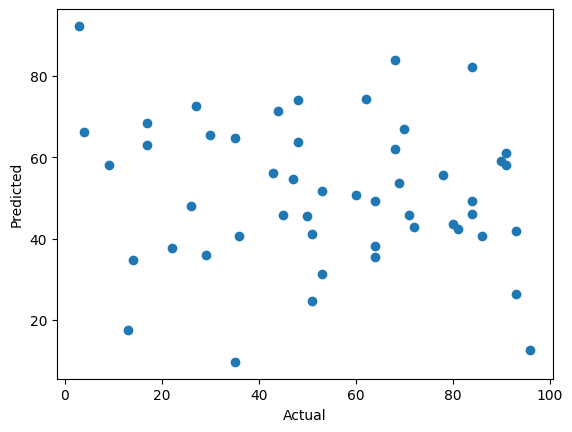

In [32]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

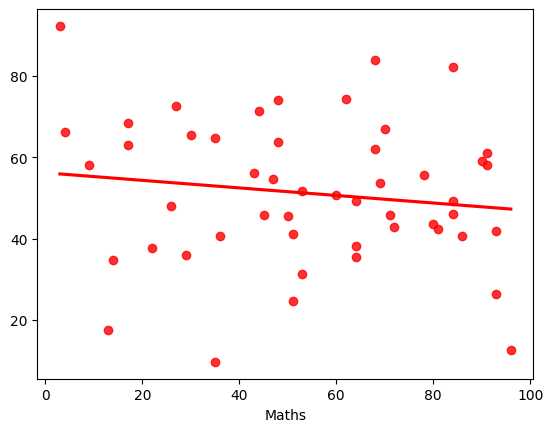

In [33]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

Difference between Actual and Predicted Values

In [34]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
142,84,82.208253,1.791747
6,60,50.767946,9.232054
97,80,43.586357,36.413643
60,14,34.639449,-20.639449
112,26,48.039895,-22.039895
181,51,41.137110,9.862890
197,4,66.207458,-62.207458
184,68,84.005040,-16.005040
9,27,72.613445,-45.613445
104,48,63.673146,-15.673146
